# Event Attendance Predictor — Model Notebook

6 classifiers: Logistic Regression, SVM (RBF), SVM (Linear), XGBoost, LightGBM, CatBoost.
Every model is class-weight balanced (313 attended vs 183 not, in train) and regularized against overfitting — we only have ~400 training rows after the hold-out split, so keeping every model simple matters more than squeezing out extra accuracy.

## Setup

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier, Pool

from pathlib import Path
import joblib

# Store all trained models in a relative subfolder next to the notebook
MODEL_DIR = Path("model")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

## Load Data

`test_clean.csv` is the real unlabeled Kaggle test set (no `attended` column) — only used at the end for final probability predictions. All scoring below uses a stratified hold-out split carved out of `train_clean.csv`.

In [41]:
train = pd.read_csv("train_clean.csv")
test = pd.read_csv("test_clean.csv")

TARGET = "attended"
NUM_FEATURES = ["registration_days_before", "previous_events_registered",
                "previous_events_attended", "club_member", "event_time", "travel_distance_km"]
CAT_FEATURES = ["event_type", "event_day"]
FEATURES = NUM_FEATURES + CAT_FEATURES

X, y = train[FEATURES], train[TARGET]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test (unlabeled):", test.shape)
print("Train class balance:\n", y_train.value_counts())

Train: (396, 8)  Val: (100, 8)  Test (unlabeled): (100, 9)
Train class balance:
 attended
1    250
0    146
Name: count, dtype: int64


## Class Imbalance

Attended (1) outnumbers not-attended (0) roughly 63/37 in this data. Every model below is told about this explicitly — `class_weight="balanced"` for the sklearn/LightGBM models, `scale_pos_weight` for XGBoost, `auto_class_weights="Balanced"` for CatBoost — instead of learning to just favor the majority class.

## Evaluation Helper

In [42]:
results = []

def evaluate(name, y_true, y_pred, y_proba):
    row = {"model": name, "precision": precision_score(y_true, y_pred),
           "recall": recall_score(y_true, y_pred), "f1": f1_score(y_true, y_pred),
           "auc": roc_auc_score(y_true, y_proba)}
    results.append(row)
    print(name)
    print(classification_report(y_true, y_pred, target_names=["No", "Yes"]))
    print(f"AUC: {row['auc']:.4f}")
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(3.5, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No","Yes"], yticklabels=["No","Yes"])
    plt.title(f"{name} — Confusion Matrix"); plt.ylabel("Actual"); plt.xlabel("Predicted")
    plt.tight_layout(); plt.show()
    return row

## Model 1: CatBoost

Trained on raw `event_type`/`event_day` strings — no one-hot needed, CatBoost encodes categoricals internally.
**Regularization:** shallow `depth=4`, small `iterations=300`, and `l2_leaf_reg=6` (well above the default of 3) to keep it from memorizing 400 rows.

CatBoost
              precision    recall  f1-score   support

          No       0.52      0.68      0.59        37
         Yes       0.77      0.63      0.70        63

    accuracy                           0.65       100
   macro avg       0.65      0.66      0.64       100
weighted avg       0.68      0.65      0.66       100

AUC: 0.7181


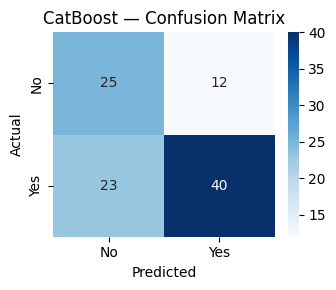

{'model': 'CatBoost',
 'precision': 0.7692307692307693,
 'recall': 0.6349206349206349,
 'f1': 0.6956521739130435,
 'auc': 0.7181467181467182}

In [30]:
cb_train_pool = Pool(X_train, y_train, cat_features=CAT_FEATURES)
cb_val_pool = Pool(X_val, y_val, cat_features=CAT_FEATURES)

cb_model = CatBoostClassifier(
    depth=4, iterations=300, learning_rate=0.05, l2_leaf_reg=6,
    auto_class_weights="Balanced", verbose=False, random_state=42
)
cb_model.fit(cb_train_pool)
evaluate("CatBoost", y_val, cb_model.predict(cb_val_pool), cb_model.predict_proba(cb_val_pool)[:, 1])

## Encoding for LR / SVM / XGBoost / LightGBM

Logistic Regression and SVM are distance/gradient-based and need scaled numeric features; XGBoost and LightGBM split on raw thresholds and don't.

In [31]:
scaled_prep = ColumnTransformer([("num", StandardScaler(), NUM_FEATURES),
                                  ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_FEATURES)])
unscaled_prep = ColumnTransformer([("num", "passthrough", NUM_FEATURES),
                                    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_FEATURES)])

## Model 2: Logistic Regression

**Regularization:** `C=0.1` — strong L2 penalty (default is `C=1.0`; lower `C` = more regularization). `class_weight="balanced"` reweights the loss for the minority class.

Logistic Regression
              precision    recall  f1-score   support

          No       0.47      0.62      0.53        37
         Yes       0.73      0.59      0.65        63

    accuracy                           0.60       100
   macro avg       0.60      0.60      0.59       100
weighted avg       0.63      0.60      0.61       100

AUC: 0.6843


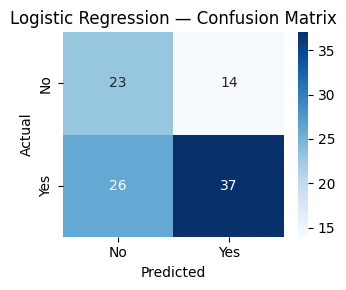

{'model': 'Logistic Regression',
 'precision': 0.7254901960784313,
 'recall': 0.5873015873015873,
 'f1': 0.6491228070175439,
 'auc': 0.6842556842556843}

In [32]:
lr_pipe = Pipeline([("prep", scaled_prep),
                     ("clf", LogisticRegression(C=0.1, class_weight="balanced", max_iter=1000, random_state=42))])
lr_pipe.fit(X_train, y_train)
evaluate("Logistic Regression", y_val, lr_pipe.predict(X_val), lr_pipe.predict_proba(X_val)[:, 1])

## Model 3: SVM — RBF kernel

**Regularization:** `C=1.0` (moderate margin softness) with `class_weight="balanced"`. `gamma="scale"` avoids an overly wiggly boundary on this few rows.

SVM (RBF)
              precision    recall  f1-score   support

          No       0.52      0.65      0.58        37
         Yes       0.76      0.65      0.70        63

    accuracy                           0.65       100
   macro avg       0.64      0.65      0.64       100
weighted avg       0.67      0.65      0.66       100

AUC: 0.6804


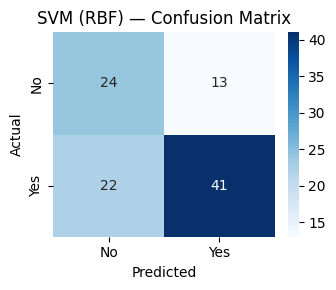

{'model': 'SVM (RBF)',
 'precision': 0.7592592592592593,
 'recall': 0.6507936507936508,
 'f1': 0.7008547008547008,
 'auc': 0.6803946803946804}

In [33]:
svm_rbf_pipe = Pipeline([("prep", scaled_prep),
                          ("clf", SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced",
                                      probability=True, random_state=42))])
svm_rbf_pipe.fit(X_train, y_train)
evaluate("SVM (RBF)", y_val, svm_rbf_pipe.predict(X_val), svm_rbf_pipe.predict_proba(X_val)[:, 1])

## Model 4: SVM — Linear kernel

A linear decision boundary is inherently lower-variance than RBF — a good regularized counterpart to compare against, especially with this little data. **Regularization:** `C=0.5`, tighter margin than the RBF version.

SVM (Linear)
              precision    recall  f1-score   support

          No       0.47      0.54      0.50        37
         Yes       0.70      0.63      0.67        63

    accuracy                           0.60       100
   macro avg       0.58      0.59      0.58       100
weighted avg       0.61      0.60      0.60       100

AUC: 0.6568


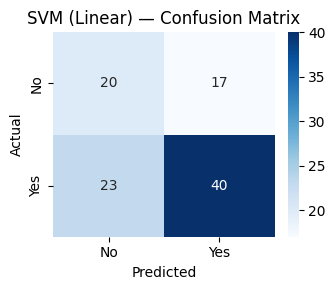

{'model': 'SVM (Linear)',
 'precision': 0.7017543859649122,
 'recall': 0.6349206349206349,
 'f1': 0.6666666666666666,
 'auc': 0.6567996567996568}

In [34]:
svm_lin_pipe = Pipeline([("prep", scaled_prep),
                          ("clf", SVC(kernel="linear", C=0.5, class_weight="balanced",
                                      probability=True, random_state=42))])
svm_lin_pipe.fit(X_train, y_train)
evaluate("SVM (Linear)", y_val, svm_lin_pipe.predict(X_val), svm_lin_pipe.predict_proba(X_val)[:, 1])

## Model 5: XGBoost

**Regularization:** shallow `max_depth=3`, low `learning_rate=0.05`, row/column subsampling (`subsample=0.8`, `colsample_bytree=0.8`), and explicit `reg_alpha`/`reg_lambda` (L1/L2 on leaf weights) — all pushing against overfitting on ~400 rows. `scale_pos_weight` handles the class imbalance.

XGBoost
              precision    recall  f1-score   support

          No       0.50      0.68      0.57        37
         Yes       0.76      0.60      0.67        63

    accuracy                           0.63       100
   macro avg       0.63      0.64      0.62       100
weighted avg       0.66      0.63      0.64       100

AUC: 0.6782


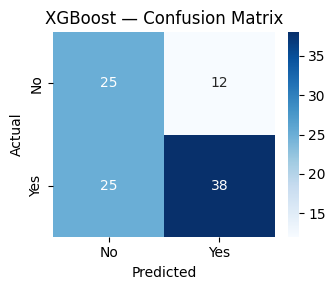

{'model': 'XGBoost',
 'precision': 0.76,
 'recall': 0.6031746031746031,
 'f1': 0.672566371681416,
 'auc': 0.6782496782496782}

In [35]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_pipe = Pipeline([("prep", unscaled_prep),
                      ("clf", XGBClassifier(max_depth=3, learning_rate=0.05, n_estimators=200,
                                             subsample=0.8, colsample_bytree=0.8,
                                             reg_alpha=1.0, reg_lambda=2.0,
                                             scale_pos_weight=scale_pos_weight,
                                             eval_metric="logloss", random_state=42))])
xgb_pipe.fit(X_train, y_train)
evaluate("XGBoost", y_val, xgb_pipe.predict(X_val), xgb_pipe.predict_proba(X_val)[:, 1])

## Model 6: LightGBM

**Regularization:** shallow `max_depth=4` with a capped `num_leaves=15` (LightGBM grows leaf-wise, so `num_leaves` matters more than depth alone), `min_child_samples=20` to stop it splitting on tiny/noisy groups, plus `reg_alpha`/`reg_lambda` and subsampling. `class_weight="balanced"` for the imbalance.

LightGBM
              precision    recall  f1-score   support

          No       0.55      0.70      0.62        37
         Yes       0.79      0.67      0.72        63

    accuracy                           0.68       100
   macro avg       0.67      0.68      0.67       100
weighted avg       0.70      0.68      0.69       100

AUC: 0.7113


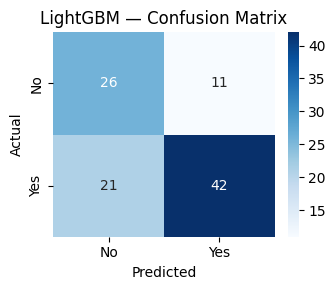

{'model': 'LightGBM',
 'precision': 0.7924528301886793,
 'recall': 0.6666666666666666,
 'f1': 0.7241379310344828,
 'auc': 0.7112827112827114}

In [36]:
lgbm_pipe = Pipeline([("prep", unscaled_prep),
                       ("clf", LGBMClassifier(max_depth=4, num_leaves=15, min_child_samples=20,
                                               learning_rate=0.05, n_estimators=200,
                                               subsample=0.8, colsample_bytree=0.8,
                                               reg_alpha=1.0, reg_lambda=1.0,
                                               class_weight="balanced", random_state=42, verbose=-1))])
lgbm_pipe.fit(X_train, y_train)
evaluate("LightGBM", y_val, lgbm_pipe.predict(X_val), lgbm_pipe.predict_proba(X_val)[:, 1])

In [37]:
# Save every trained model as a separate Joblib file under the relative `model/` subfolder.
# The paths are relative to the notebook's current working directory.
model_paths = {
    "CatBoost": MODEL_DIR / "catboost.joblib",
    "Logistic Regression": MODEL_DIR / "logistic_regression.joblib",
    "SVM (RBF)": MODEL_DIR / "svm_rbf.joblib",
    "SVM (Linear)": MODEL_DIR / "svm_linear.joblib",
    "XGBoost": MODEL_DIR / "xgboost.joblib",
    "LightGBM": MODEL_DIR / "lightgbm.joblib",
}

trained_models = {
    "CatBoost": cb_model,
    "Logistic Regression": lr_pipe,
    "SVM (RBF)": svm_rbf_pipe,
    "SVM (Linear)": svm_lin_pipe,
    "XGBoost": xgb_pipe,
    "LightGBM": lgbm_pipe,
}

for name, model in trained_models.items():
    joblib.dump(model, model_paths[name])
    print(f"Saved {name} -> {model_paths[name]}")


Saved CatBoost -> model\catboost.joblib
Saved Logistic Regression -> model\logistic_regression.joblib
Saved SVM (RBF) -> model\svm_rbf.joblib
Saved SVM (Linear) -> model\svm_linear.joblib
Saved XGBoost -> model\xgboost.joblib
Saved LightGBM -> model\lightgbm.joblib


## Model Comparison

,precision,recall,f1,auc
model,,,,
LightGBM,0.7925,0.6667,0.7241,0.7113
SVM (RBF),0.7593,0.6508,0.7009,0.6804
CatBoost,0.7692,0.6349,0.6957,0.7181
XGBoost,0.7600,0.6032,0.6726,0.6782
SVM (Linear),0.7018,0.6349,0.6667,0.6568
Logistic Regression,0.7255,0.5873,0.6491,0.6843


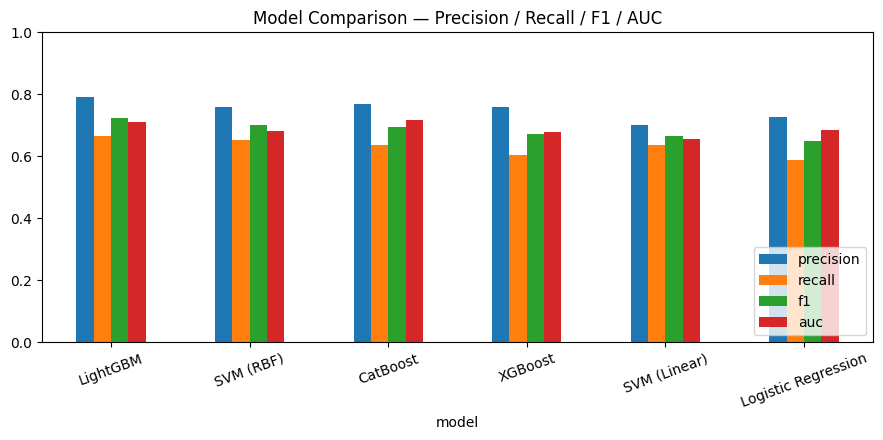

In [38]:
results_df = pd.DataFrame(results).set_index("model").round(4).sort_values("f1", ascending=False)
display(results_df)

results_df.plot(kind="bar", figsize=(9, 4.5), rot=20)
plt.title("Model Comparison — Precision / Recall / F1 / AUC")
plt.ylim(0, 1); plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

## Final Predictions on the Real (Unlabeled) Test Set

Best model by F1 predicts on `test_clean.csv`, output matching the task's expected format.

In [39]:
best_name = results_df.index[0]
print("Best model by F1:", best_name)

models = {"CatBoost": ("cb", cb_model), "Logistic Regression": ("sk", lr_pipe),
          "SVM (RBF)": ("sk", svm_rbf_pipe), "SVM (Linear)": ("sk", svm_lin_pipe),
          "XGBoost": ("sk", xgb_pipe), "LightGBM": ("sk", lgbm_pipe)}
kind, best_model = models[best_name]
print("Saved model file:", model_paths[best_name])

if kind == "cb":
    test_proba = best_model.predict_proba(Pool(test[FEATURES], cat_features=CAT_FEATURES))[:, 1]
else:
    test_proba = best_model.predict_proba(test[FEATURES])[:, 1]

predictions = pd.DataFrame({"student_id": test["student_id"],
                             "attendance_probability": (test_proba * 100).round(1)}
                           ).sort_values("attendance_probability", ascending=False)

for _, row in predictions.head(10).iterrows():
    print(f"{row['student_id']} -> {row['attendance_probability']}% likely to attend")

predictions.to_csv("test_predictions.csv", index=False)
predictions.head(10)

Best model by F1: LightGBM
Saved model file: model\lightgbm.joblib
S1015 -> 94.5% likely to attend
S1475 -> 94.0% likely to attend
S1005 -> 93.6% likely to attend
S1055 -> 93.1% likely to attend
S1173 -> 92.2% likely to attend
S1379 -> 91.8% likely to attend
S1313 -> 88.6% likely to attend
S1414 -> 87.8% likely to attend
S1033 -> 86.7% likely to attend
S1069 -> 85.0% likely to attend


,student_id,attendance_probability
50,S1015,94.5
89,S1475,94.0
32,S1005,93.6
87,S1055,93.1
49,S1173,92.2
0,S1379,91.8
13,S1313,88.6
12,S1414,87.8
78,S1033,86.7
53,S1069,85.0
